## 1. Unified Setup and Paths

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from pathlib import Path
import joblib  
import torch

# --- CONSTANTS & PATHS ---
WINDOW_SIZE = 30
MAX_RUL = 125
TARGET = "RUL_clipped"

# 1. Load Data
DATA_PATH = Path("../data/experiments/DS-C")
MODEL_PATH_ML = Path("../artifacts/random_forest_model.joblib")
MODEL_PATH_DL = Path("../artifacts/lstm_model.pth")

train_df = pd.read_csv(DATA_PATH / "train.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv")

# Identify PC features (PC_1 to PC_33)
feature_cols = [c for c in train_df.columns if c.startswith('PC_')]



In [6]:
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor

# --- 1. Model Definitions & Scoring ---

# NASA Scoring Function (From your DS-C notebook)
def nasa_scoring_function(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(score)

# LSTM Class definition (Required to load the .pth model)
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # Use Sequential head to match saved checkpoint architecture
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, (hn, cn) = self.lstm(x, (h_0, c_0))
        
        internal_features = hn[-1] # 提取用于 Anomaly Detection 的特征
        out = self.head(out[:, -1, :])
        return out, internal_features

In [8]:
# --- 2. Load the Models ---

# Load Traditional ML (Random Forest)
rf_model = joblib.load(MODEL_PATH_ML)

# Load Deep Learning (LSTM)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(MODEL_PATH_DL, map_location=device)

# Extract architecture params from checkpoint metadata
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    input_dim = checkpoint.get('input_dim', 33)
    hidden_dim = checkpoint.get('hidden_dim', 64)
    num_layers = checkpoint.get('num_layers', 2)
    output_dim = checkpoint.get('output_dim', 1)
    state_dict = checkpoint['model_state_dict']
else:
    input_dim, hidden_dim, num_layers, output_dim = 33, 64, 2, 1
    state_dict = checkpoint

# The checkpoint uses a simpler architecture with 'fc' layer
# Define a matching model class
class SimpleLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(SimpleLSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, (hn, cn) = self.lstm(x, (h_0, c_0))
        internal_features = hn[-1]  # Hidden state for anomaly detection
        out = self.fc(out[:, -1, :])
        return out, internal_features

# Instantiate and load
model_dl = SimpleLSTMModel(input_dim=input_dim, hidden_dim=hidden_dim, 
                           num_layers=num_layers, output_dim=output_dim).to(device)
model_dl.load_state_dict(state_dict)
model_dl.eval()

print(f"✅ Model loaded with: input_dim={input_dim}, hidden_dim={hidden_dim}, num_layers={num_layers}")

✅ Model loaded with: input_dim=33, hidden_dim=64, num_layers=2


In [9]:
# --- 3. Differentiated Data Preparation ---

# Random Forest uses all 33 PCs
ml_feature_cols = [f'PC_{i}' for i in range(1, 34)]

# LSTM was trained on all 33 PCs (matching the checkpoint)
dl_feature_cols = [f'PC_{i}' for i in range(1, 34)]

target_col = 'RUL_clipped' 

# A. Prepare for Random Forest (All 33 Features)
test_ml = test_df.groupby('unit_number').last().reset_index()
X_ml = test_ml[ml_feature_cols]
y_true = test_ml[target_col]
unit_ids = test_ml['unit_number']

# B. Prepare for LSTM (All 33 Features - to match checkpoint)
dl_windows = []
for unit in unit_ids:
    unit_data = test_df[test_df['unit_number'] == unit]
    window = unit_data[dl_feature_cols].values[-WINDOW_SIZE:]
    dl_windows.append(window)

# Convert to tensor - will be [Batch, 30, 33] to match checkpoint
X_dl_tensor = torch.tensor(np.array(dl_windows), dtype=torch.float32).to(device)

In [10]:
# --- 4. Get Predictions & Create Summary ---

# Predictions
preds_rf = rf_model.predict(X_ml)

model_dl.eval()
with torch.no_grad():
    preds_dl_tensor, lstm_internal_features = model_dl(X_dl_tensor)
    
    preds_dl = preds_dl_tensor.cpu().numpy().flatten()
    lstm_features_np = lstm_internal_features.cpu().numpy()

combined_features = np.hstack([X_ml, lstm_features_np])

print(f"Feature dimensions after fusion: {combined_features.shape}") 
# Summary DataFrame
summary_df = pd.DataFrame({
    'Unit': unit_ids.astype(int),
    'Actual_RUL': y_true.values,
    'RF_Prediction': preds_rf,
    'LSTM_Prediction': preds_dl
})

summary_df['Ensemble_Prediction'] = (summary_df['RF_Prediction'] * 0.90) + (summary_df['LSTM_Prediction'] * 0.10)

# Final Scoring
ensemble_nasa = nasa_scoring_function(summary_df['Actual_RUL'], summary_df['Ensemble_Prediction'])

print(f"Ensemble NASA Score: {ensemble_nasa:.2f}")
display(summary_df.head(10))

Feature dimensions after fusion: (100, 97)
Ensemble NASA Score: 797.34


,Unit,Actual_RUL,RF_Prediction,LSTM_Prediction,Ensemble_Prediction
0,1,112.0,114.684132,123.635719,115.579291
1,2,98.0,111.315674,115.366753,111.720782
2,3,69.0,57.159474,38.779949,55.321522
3,4,82.0,97.239630,84.055878,95.921255
4,5,91.0,107.154252,85.611687,104.999995
5,6,93.0,108.412199,106.249924,108.195971
6,7,91.0,100.122445,123.635025,102.473703
7,8,95.0,102.966371,87.636894,101.433424
8,9,111.0,109.960406,117.689171,110.733282
9,10,96.0,106.412000,123.632790,108.134079


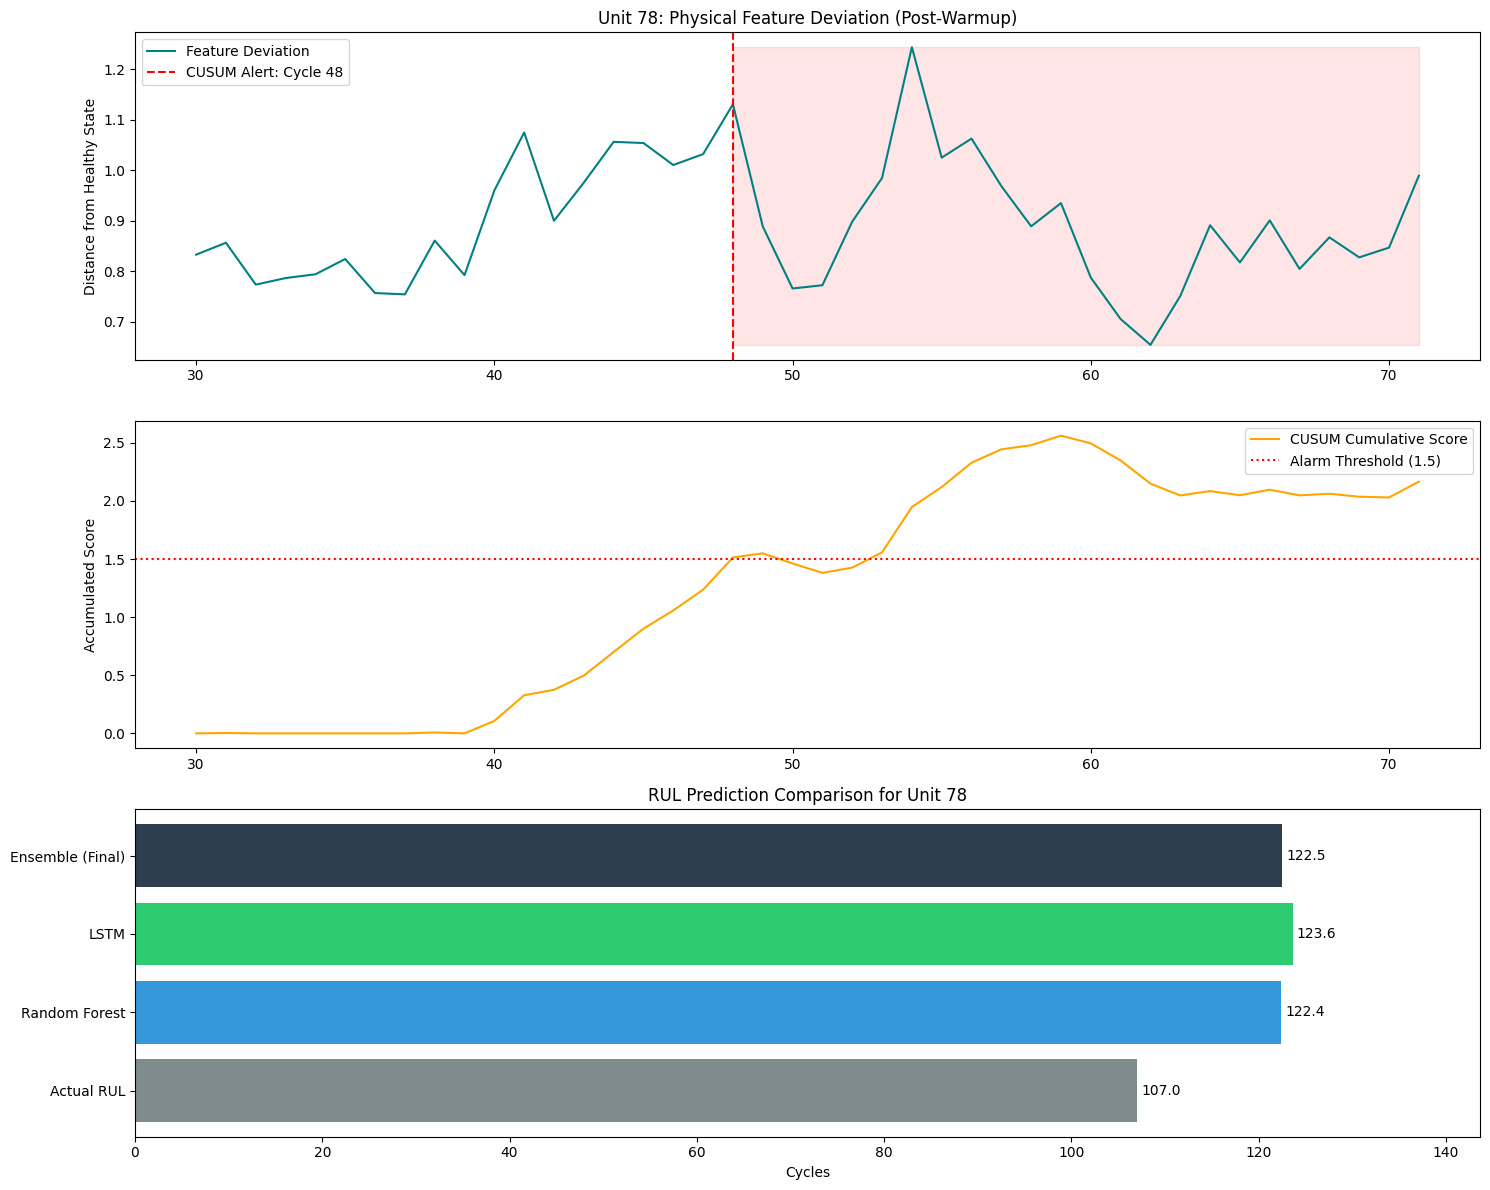


DIGNOSTIC REPORT: ENGINE UNIT 78
【RUL PREDICTION】
 - Ground Truth (Actual): 107.0 cycles
 - AI Ensemble Prediction: 122.53 cycles

【STATUS CHECK】
 - Health Grade: Healthy
 - Anomaly Status: Normal

【TREND ANALYSIS】
 - Result: ⚠️ DEGRADATION DETECTED
 - Confirmed Change-Point: Cycle 48
 - Insight: Sustained physical deviation confirmed. Predictive maintenance recommended.


In [29]:
import matplotlib.pyplot as plt

def detect_cusum(series, target_mean, drift=0.05, threshold=5):
    """
    CUSUM 算法实现
    series: 监测的信号 (例如 LSTM 的预测误差)
    target_mean: 正常运行阶段的平均值
    drift (k): 容忍的波动偏移量
    threshold (h): 触发报警的累计阈值
    """
    pos_sum = np.zeros(len(series))
    change_point = None
    
    for i in range(1, len(series)):
        # 计算累积正向偏差：S_i = max(0, S_{i-1} + (x_i - mean - k))
        deviation = series[i] - target_mean - drift
        pos_sum[i] = max(0, pos_sum[i-1] + deviation)
        
        if pos_sum[i] > threshold and change_point is None:
            change_point = i  # 锁定退化开始的 Cycle
            
    return pos_sum, change_point

# --- 1. 选择要分析的 Unit ---
unit_to_plot = 78  # 你可以修改为 14, 79 等
warmup_period = 30 # 预热期：跳过开机前 30 个周期的不稳定数据

# 从你定义的 summary_df 中提取该 Unit 的所有预测结果
unit_summary = summary_df[summary_df['Unit'] == unit_to_plot].iloc[0]

# --- 2. 获取并清洗该 Unit 的时序数据 ---
# 使用 test_df (确保你代码中 feature_cols 已经定义)
unit_ts_data = test_df[test_df['unit_number'] == unit_to_plot].copy().reset_index(drop=True)

if len(unit_ts_data) > warmup_period:
    # 只分析稳定期后的数据
    unit_ts_active = unit_ts_data.iloc[warmup_period:].copy().reset_index(drop=True)
    
    # 计算特征偏移距离 (基于你定义的 feature_cols)
    unit_features = unit_ts_active[feature_cols].values
    base_mean = unit_features[:10].mean(axis=0) # 以稳定后的前10步为健康基准
    deviation_signal = np.linalg.norm(unit_features - base_mean, axis=1)

    # 运行 CUSUM 检测
    target_dist = deviation_signal[:10].mean()
    # 参数根据 NASA 数据集特性设定：drift=0.05, threshold=1.5
    cusum_vals, cp = detect_cusum(deviation_signal, target_dist, drift=0.05, threshold=1.5)

    # --- 3. 绘图：三位一体诊断图表 ---
    time_steps = np.arange(warmup_period, warmup_period + len(unit_ts_active))
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

    # 子图 1: 物理特征偏移 (反映机器是否开始“变样”)
    ax1.plot(time_steps, deviation_signal, color='teal', label='Feature Deviation')
    if cp is not None:
        degradation_cycle = time_steps[cp]
        ax1.axvline(x=degradation_cycle, color='red', linestyle='--', label=f'CUSUM Alert: Cycle {degradation_cycle}')
        ax1.fill_between(time_steps[cp:], min(deviation_signal), max(deviation_signal), color='red', alpha=0.1)
    ax1.set_title(f'Unit {unit_to_plot}: Physical Feature Deviation (Post-Warmup)')
    ax1.set_ylabel('Distance from Healthy State')
    ax1.legend()

    # 子图 2: CUSUM 累积得分 (反映退化趋势的强度)
    ax2.plot(time_steps, cusum_vals, color='orange', label='CUSUM Cumulative Score')
    ax2.axhline(y=1.5, color='red', linestyle=':', label='Alarm Threshold (1.5)')
    ax2.set_ylabel('Accumulated Score')
    ax2.legend()

    # 子图 3: RUL 预测对比 (对比 True, RF, LSTM, Ensemble)
    labels = ['Actual RUL', 'Random Forest', 'LSTM', 'Ensemble (Final)']
    # 严格使用你代码中的变量名
    rul_comparison = [
        unit_summary['Actual_RUL'], 
        unit_summary['RF_Prediction'], 
        unit_summary['LSTM_Prediction'], 
        unit_summary['Ensemble_Prediction']
    ]
    
    colors = ['#7f8c8d', '#3498db', '#2ecc71', '#2c3e50']
    bars = ax3.barh(labels, rul_comparison, color=colors)
    ax3.bar_label(bars, fmt='%.1f', padding=3)
    ax3.set_title(f'RUL Prediction Comparison for Unit {unit_to_plot}')
    ax3.set_xlabel('Cycles')
    ax3.set_xlim(0, max(rul_comparison) + 20)

    plt.tight_layout()
    plt.show()

    # --- 4. 自动生成诊断报告 ---
    print(f"\n" + "="*60)
    print(f"DIGNOSTIC REPORT: ENGINE UNIT {unit_to_plot}")
    print("="*60)
    print(f"【RUL PREDICTION】")
    print(f" - Ground Truth (Actual): {unit_summary['Actual_RUL']} cycles")
    print(f" - AI Ensemble Prediction: {unit_summary['Ensemble_Prediction']:.2f} cycles")
    
    print(f"\n【STATUS CHECK】")
    print(f" - Health Grade: {unit_summary['Health_Label']}")
    print(f" - Anomaly Status: {unit_summary['Anomaly_Status']}")
    
    print(f"\n【TREND ANALYSIS】")
    if cp is not None:
        print(f" - Result: ⚠️ DEGRADATION DETECTED")
        print(f" - Confirmed Change-Point: Cycle {degradation_cycle}")
        print(f" - Insight: Sustained physical deviation confirmed. Predictive maintenance recommended.")
    else:
        print(f" - Result: ✅ STABLE CONDITION")
        print(f" - Insight: No sustained trend of degradation identified beyond normal operational noise.")
    print("="*60)

else:
    print(f"Unit {unit_to_plot} does not have enough data cycles for pre-warmup analysis.")